# Assignment 03: Rasters and Tables

For this assignment, you will be using Numpy, GDAL, and Pandas. Most of these questions  can be solved using methods shown in lecture. However, some cases will require you to search the internet for answers. This is intended because efficiently searching documentation or Stackoverflow is a requirement of modern programing. This assignment also requires you to obtain data (I will tell you where) and organize it correctly so that you can access is via relative paths (do not use absolute paths anywhere in this assignment).

To turn this in, create a PDF of your finished Jupyter notebook using Quarto (we will discuss this on Tuesday) and upload it to Canvas.


## Question 1

For this question, you will be using numpy to manipulate arrays in a way that works well for big data and will be using spatial tools to assess land-use change. Specifically, you will use data from a global, 300m resolution land-use, land-cover (LULC) map produced by ESACCI. They provide a wonderful time series of data from 1992-2019. If you want more information, check out their web viewer at https://maps.elie.ucl.ac.be/CCI/viewer/. Here you can view the data but also learn more about the classification regressions that uses time-series spectral data patterns to classify grid-cells into different types. I have extracted lulc maps for the country of Rwanda, which you will find in this assignment's data folder.

### Part a. 

Using the gdal package and the gdal.Open() function, open up the land-use, land-cover map for Rwanda in 2000. 

In this file, there is only 1 band in this file, so you can also access it with the GetRasterBand(1) function. Without reading the whole array, show how you can determine how many total grid-cells there are in this country.

In [ ]:
# 1A Answer

from osgeo import gdal
import numpy as np
import os, random
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import pandas as pd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Make the relative filepath
geotiff_file = 'rwanda_lulc_2000.tif'
data_directory = '../../base_data' 
geotiff_file_path = os.path.join(data_directory, geotiff_file)

# Open the file with gdal
rwanda_lulc_2000 = gdal.Open(geotiff_file_path)

#Look at the metadata for each file
print("General Metadata for Harvested Area Hectares: ", rwanda_lulc_2000.GetMetadata())

#Look at number of grid cells in the file
# because the country is not rectangular, this should be greater than the number of grid cells in the country
n_rows = rwanda_lulc_2000.RasterYSize
n_cols = rwanda_lulc_2000.RasterXSize
print('Number of grid cells in file: ', n_rows*n_cols)

#Get the band
rwanda_lulc_2000_band = rwanda_lulc_2000.GetRasterBand(1)

#Get the NoData value for each band
nodata_rwanda_2000 = rwanda_lulc_2000_band.GetNoDataValue()

#Get the shapefile for the country's shape so we can mask anything outside of that
#Using country_name to make this code chunk more reusable
country_name = 'Rwanda' 

# Load the world map from the Natural Earth data website
world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

# Filter to get just the one country
country_shape = world[world.NAME == country_name]

if country_shape.empty:
    print(f"Error: Country '{country_name}' not found in shapefile.")
else:
    #Open Raster and Reproject Shape ---

    with rasterio.open(geotiff_file_path) as src:
        #Get the raster's CRS
        raster_crs = src.crs

        #Reproject the country shape to match the raster's CRS
        country_shape_reprojected = country_shape.to_crs(raster_crs)

        #Convert the GeoPandas geometry into the format rasterio needs
        geoms_for_masking = country_shape_reprojected.geometry

        #Mask the Raster
        masked_array, masked_transform = mask(
            src, 
            geoms_for_masking, 
            crop = True,   #crops output array to country shape
            filled = True  #pixels outside shape set to nodata
        )
            
        # Get the NoData value from the source raster
        nodata_val = src.nodata
        
    # The output array is (bands, rows, cols). We just want the first band.
    data_grid = masked_array[0]

    #Count the Valid Cells, no 'nan' or nodata       
    #Add 'nan' cells to the mask
    invalid_mask = np.isnan(data_grid)
            
    #Then add nodata cells, if any
    if nodata_val is not None and not np.isnan(nodata_val):
            invalid_mask = np.logical_or(
            invalid_mask, 
            (data_grid == nodata_val)
        )

    #Define the valid cells to count as the inverse of the invalid mask, then count them
    valid_mask = ~invalid_mask
    total_valid_cells = np.sum(valid_mask)
    print(f"Total valid grid-cells in {country_name}: {total_valid_cells:,}")



c:\Users\phill\miniforge3\envs\env8222a\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


General Metadata for Harvested Area Hectares:  {'AREA_OR_POINT': 'Area', 'is_64_bit_pyramidal': 'yes', 'last_processing_by': 'justinandrewjohnson', 'last_processing_on': '1563207597.227144'}
Number of grid cells in file:  466284
Total valid grid-cells in Rwanda: 227,294


### Part b.

Using the results of part a, read the whole array into memory as a numpy array (the default option when using the ReadAsArray() function), and plot it using the matplotlib imshow command. Add a nice title to the plot describing what it is.

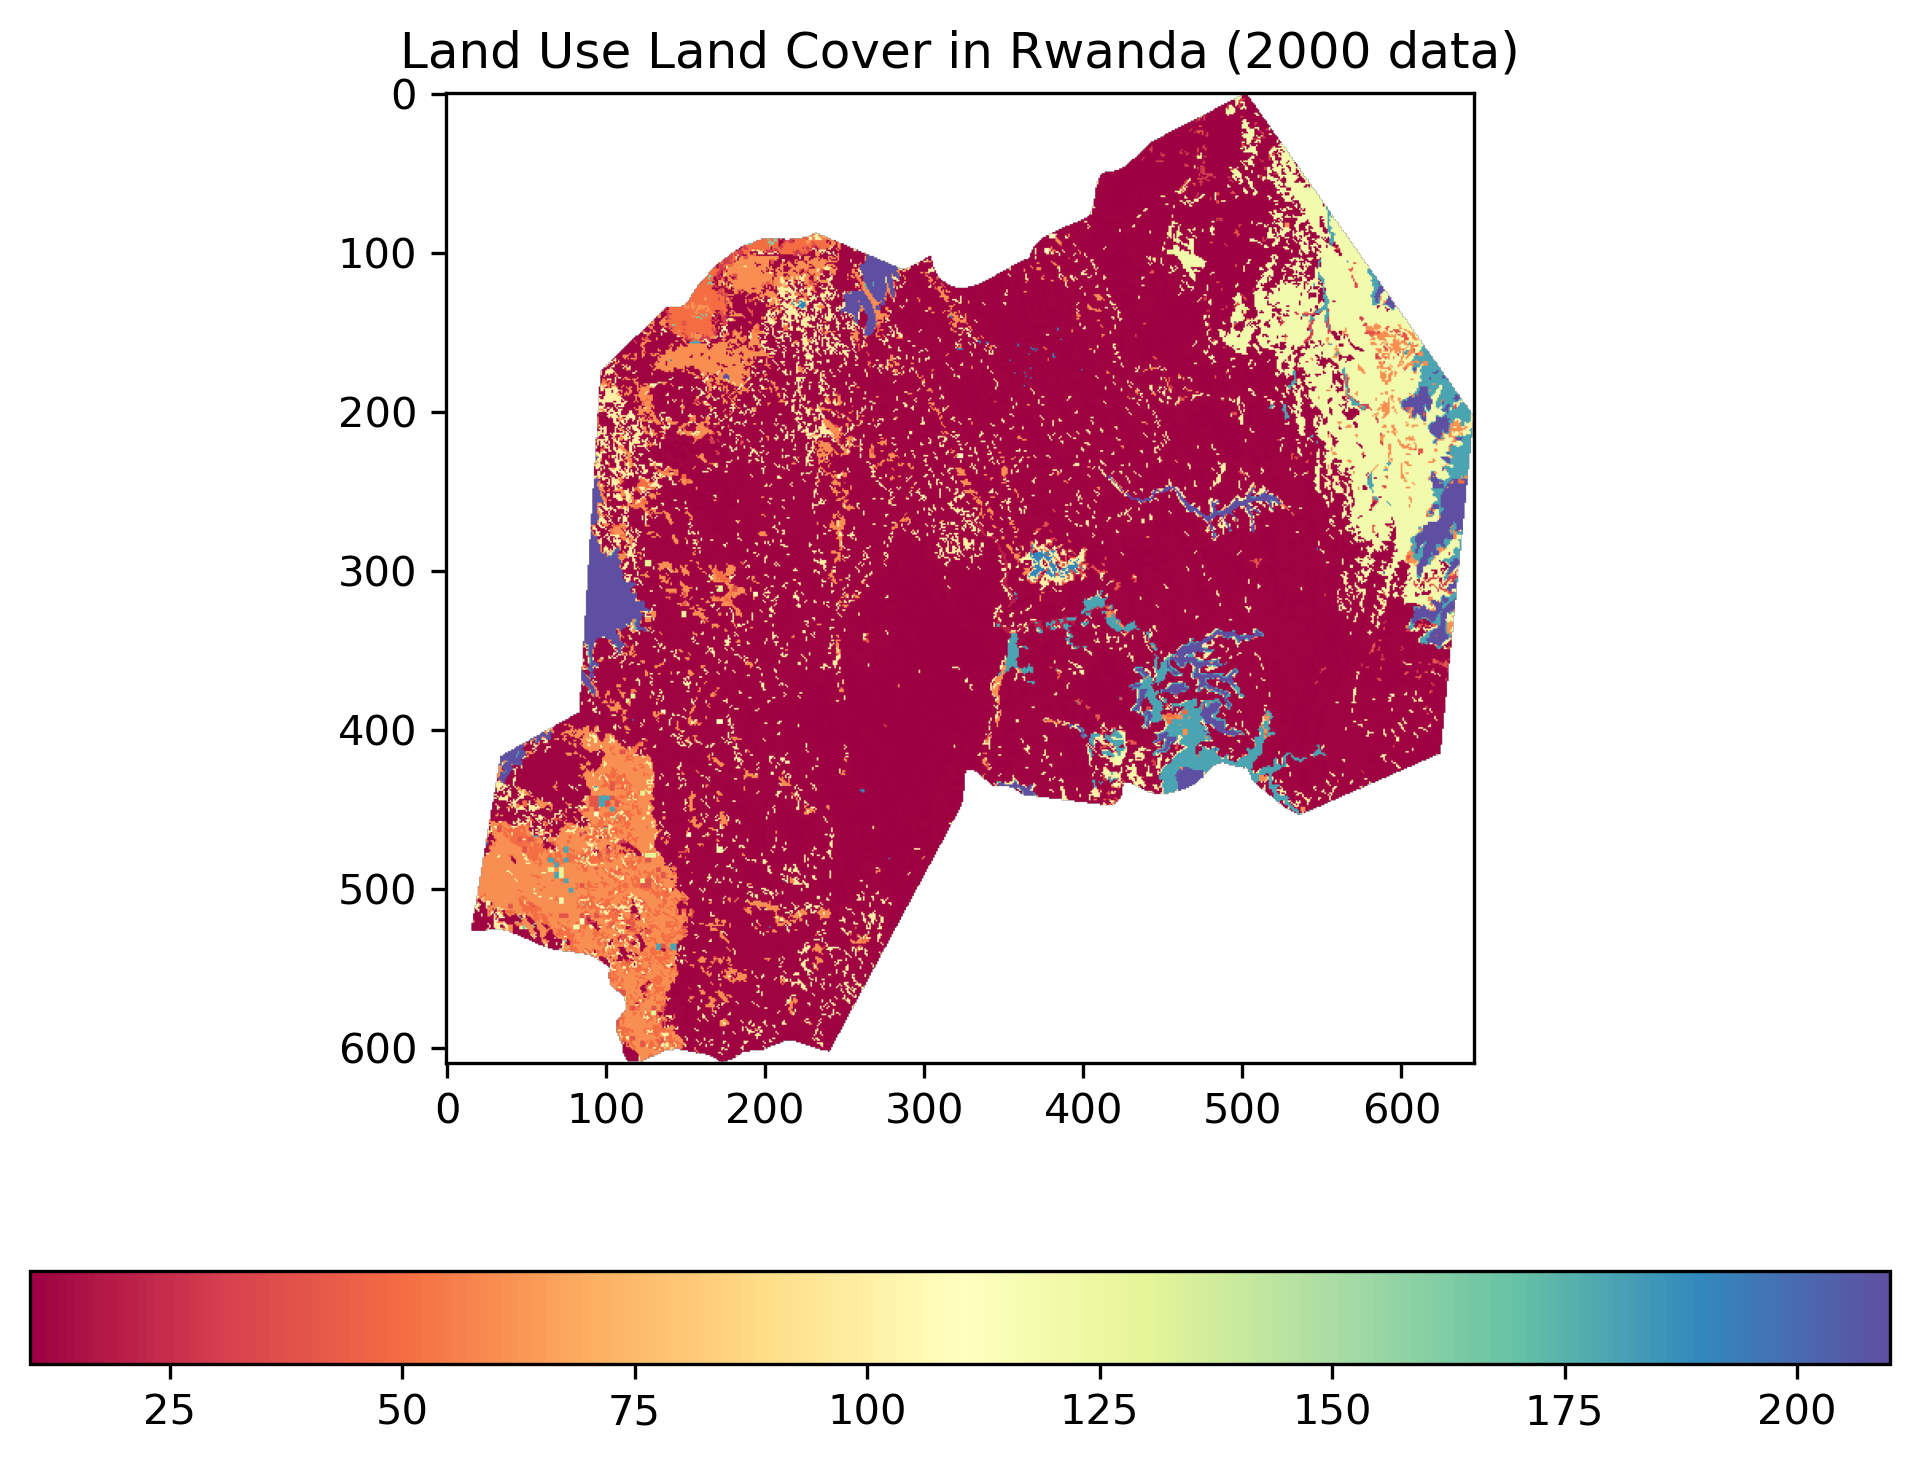

In [ ]:
#1B Answer

##Basic plot with poor color choice, commented out to display the better plot below.
##Read in as numpy array
#array = rwanda_lulc_2000_band.ReadAsArray()

##Basic visualization with title and colorbar
#plt.imshow(array)
#plt.title('Land Use Land Cover in Rwanda (2000 data)')
#plt.colorbar(orientation='horizontal')

#plt.show()


#Try #2
#First, call on masked array from part (1a) so that all grid cells outside of the country shape will be "nan" 
#Then we can make the area outside of the country borders white in a later step
array_country_only = masked_array[0].astype(float)  #we can take the first index because we know there's only one band in this file
                                                    #.astype(float) allows "nan" values
array_country_only[array_country_only == nodata_val] = np.nan  #resets "nodata" to "nan"

fig = plt.figure(figsize=(8, 6))
fig.set_dpi(300)
ax = fig.add_subplot()
ax.set_title('Land Use Land Cover in Rwanda (2000 data)')

#Create a new "im" object from our axes and array
im = ax.imshow(array_country_only)

# Get the cmap
cmap = im.get_cmap()
cmap.set_over('white', alpha=1.0)

#Time to set "nan" values to white so it doesn't look like we have data outside the country boundary
if nodata_val is not None:
   cmap.set_bad('white', alpha=1.0) # 'set_bad' is for NoData values

# Set the cbar to spectral
im.set_cmap('Spectral')

# Add the colorbar to the figure.
fig.colorbar(im, orientation='horizontal')

# Save the plot
plt.savefig('rwanda2000.png', dpi=300)

### Part c.

Using the legend you find at https://maps.elie.ucl.ac.be/CCI/viewer/download/ESACCI-LC-QuickUserGuide-LC-Maps_v2-0-7.pdf reclassify the LULC into a simplified map where 1 = cropland (including any mosaic types that are partially cropland) and 0 = anything else. Plot this using imshow.

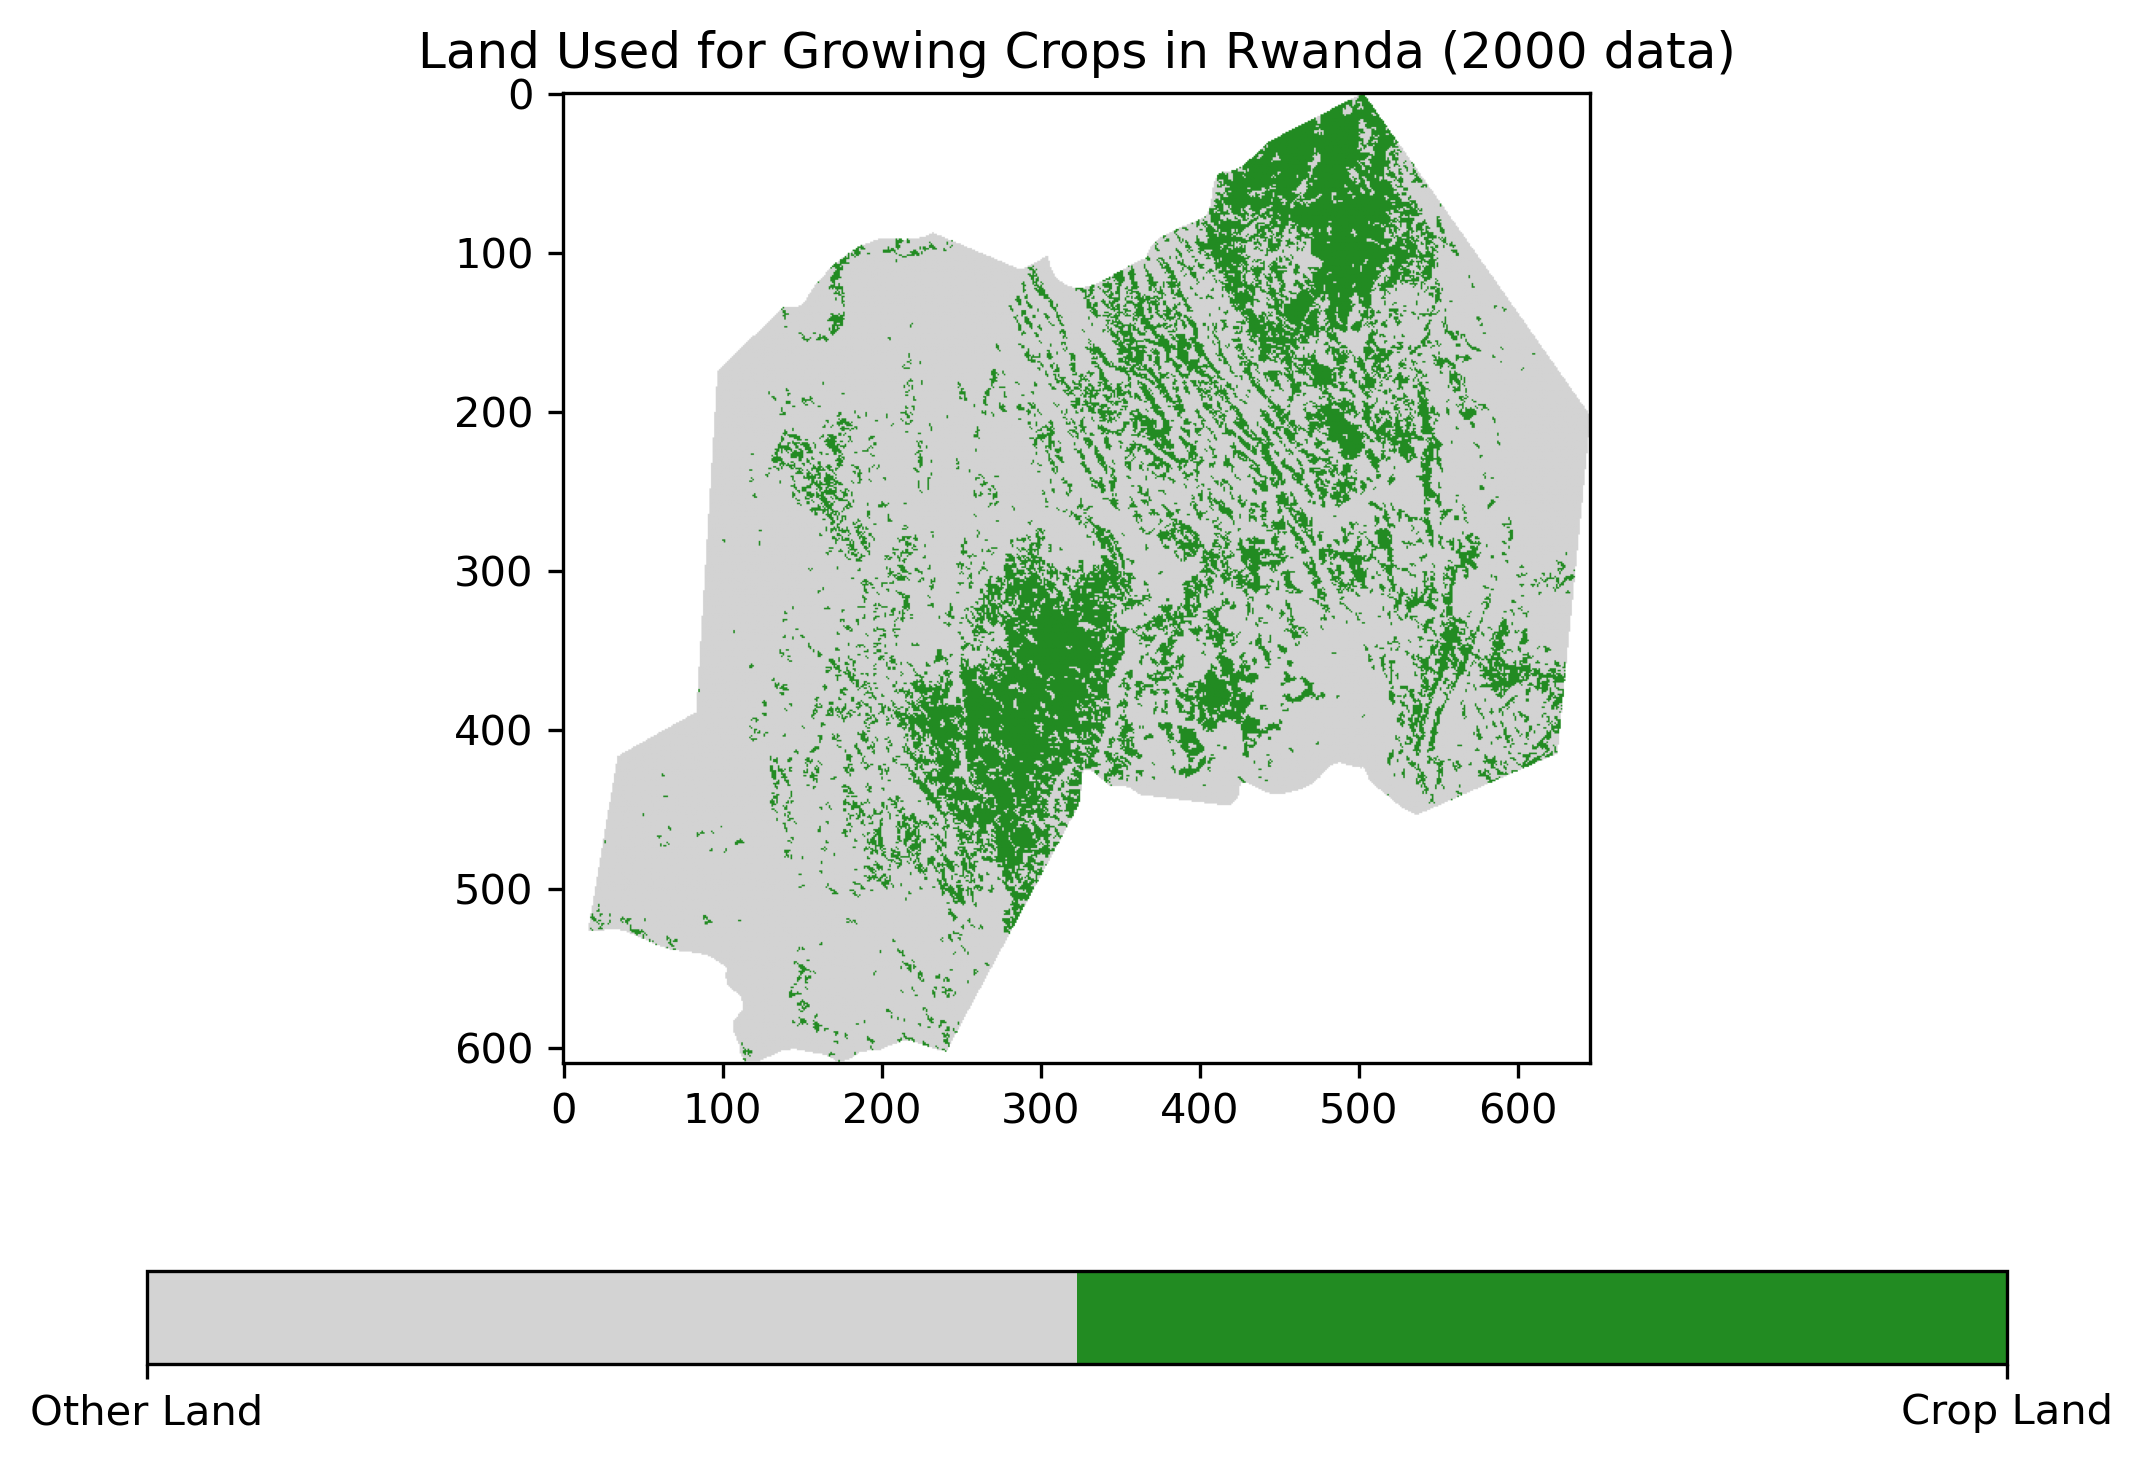

In [ ]:
# 1C Answer

#Raster values corresponding to cropland, which we'll need to change to 1
crop_values = [10, 20, 30]

#Create a boolean array with True if the value of a grid cell is in the list of crop_values, and False otherwise
crop_condition = np.isin(array_country_only, crop_values)

#Create a boolean array with True for NoData (np.nan), and False otherwise
nodata_condition = np.isnan(array_country_only)

#Apply nested logic to produce a binary map of the country, with nan outside the boundaries
new_array_2000 = np.where(
    nodata_condition,                   #check if nan
    np.nan,                             #if so, keep it as np.nan
    np.where(crop_condition, 1, 0)    #otherwise, check if it's a crop value and set to 1, or other and set 0
)

# Plot this
fig = plt.figure(figsize=(8, 6))
fig.set_dpi(300)
ax = fig.add_subplot()
ax.set_title('Land Used for Growing Crops in Rwanda (2000 data)')

#Custom colormap for binary viz
colors = ['lightgray', 'forestgreen']
custom_cmap = ListedColormap(colors)

#Set np.nan color to white
custom_cmap.set_bad('white', alpha=1.0)

#Create a new "im" object from our axes and array
im = ax.imshow(new_array_2000, cmap = custom_cmap)

#Set colorbar so it reflects only 2 values, clearly labeled
cbar = fig.colorbar(im, orientation='horizontal', ticks=[0, 1])
cbar.set_ticklabels(['Other Land', 'Crop Land'])

# Save the plot
plt.savefig('rwanda2000_croplands.png', dpi=300)

plt.show()

### Part d.

Repeat the process for the 2010 LULC map. Using this array with the one from part c, create a new array that records where there was cropland expansion (i.e., there is cropland in 2010 but not in 2000) and where there was cropland abandonment (cropland in 2000 but not in 2010). Save this classification in a single new array. Plot this last array. Optionally, add a legend indicating which values in the array denote expansion and abandonment using some variant of `ax.legend()'. 

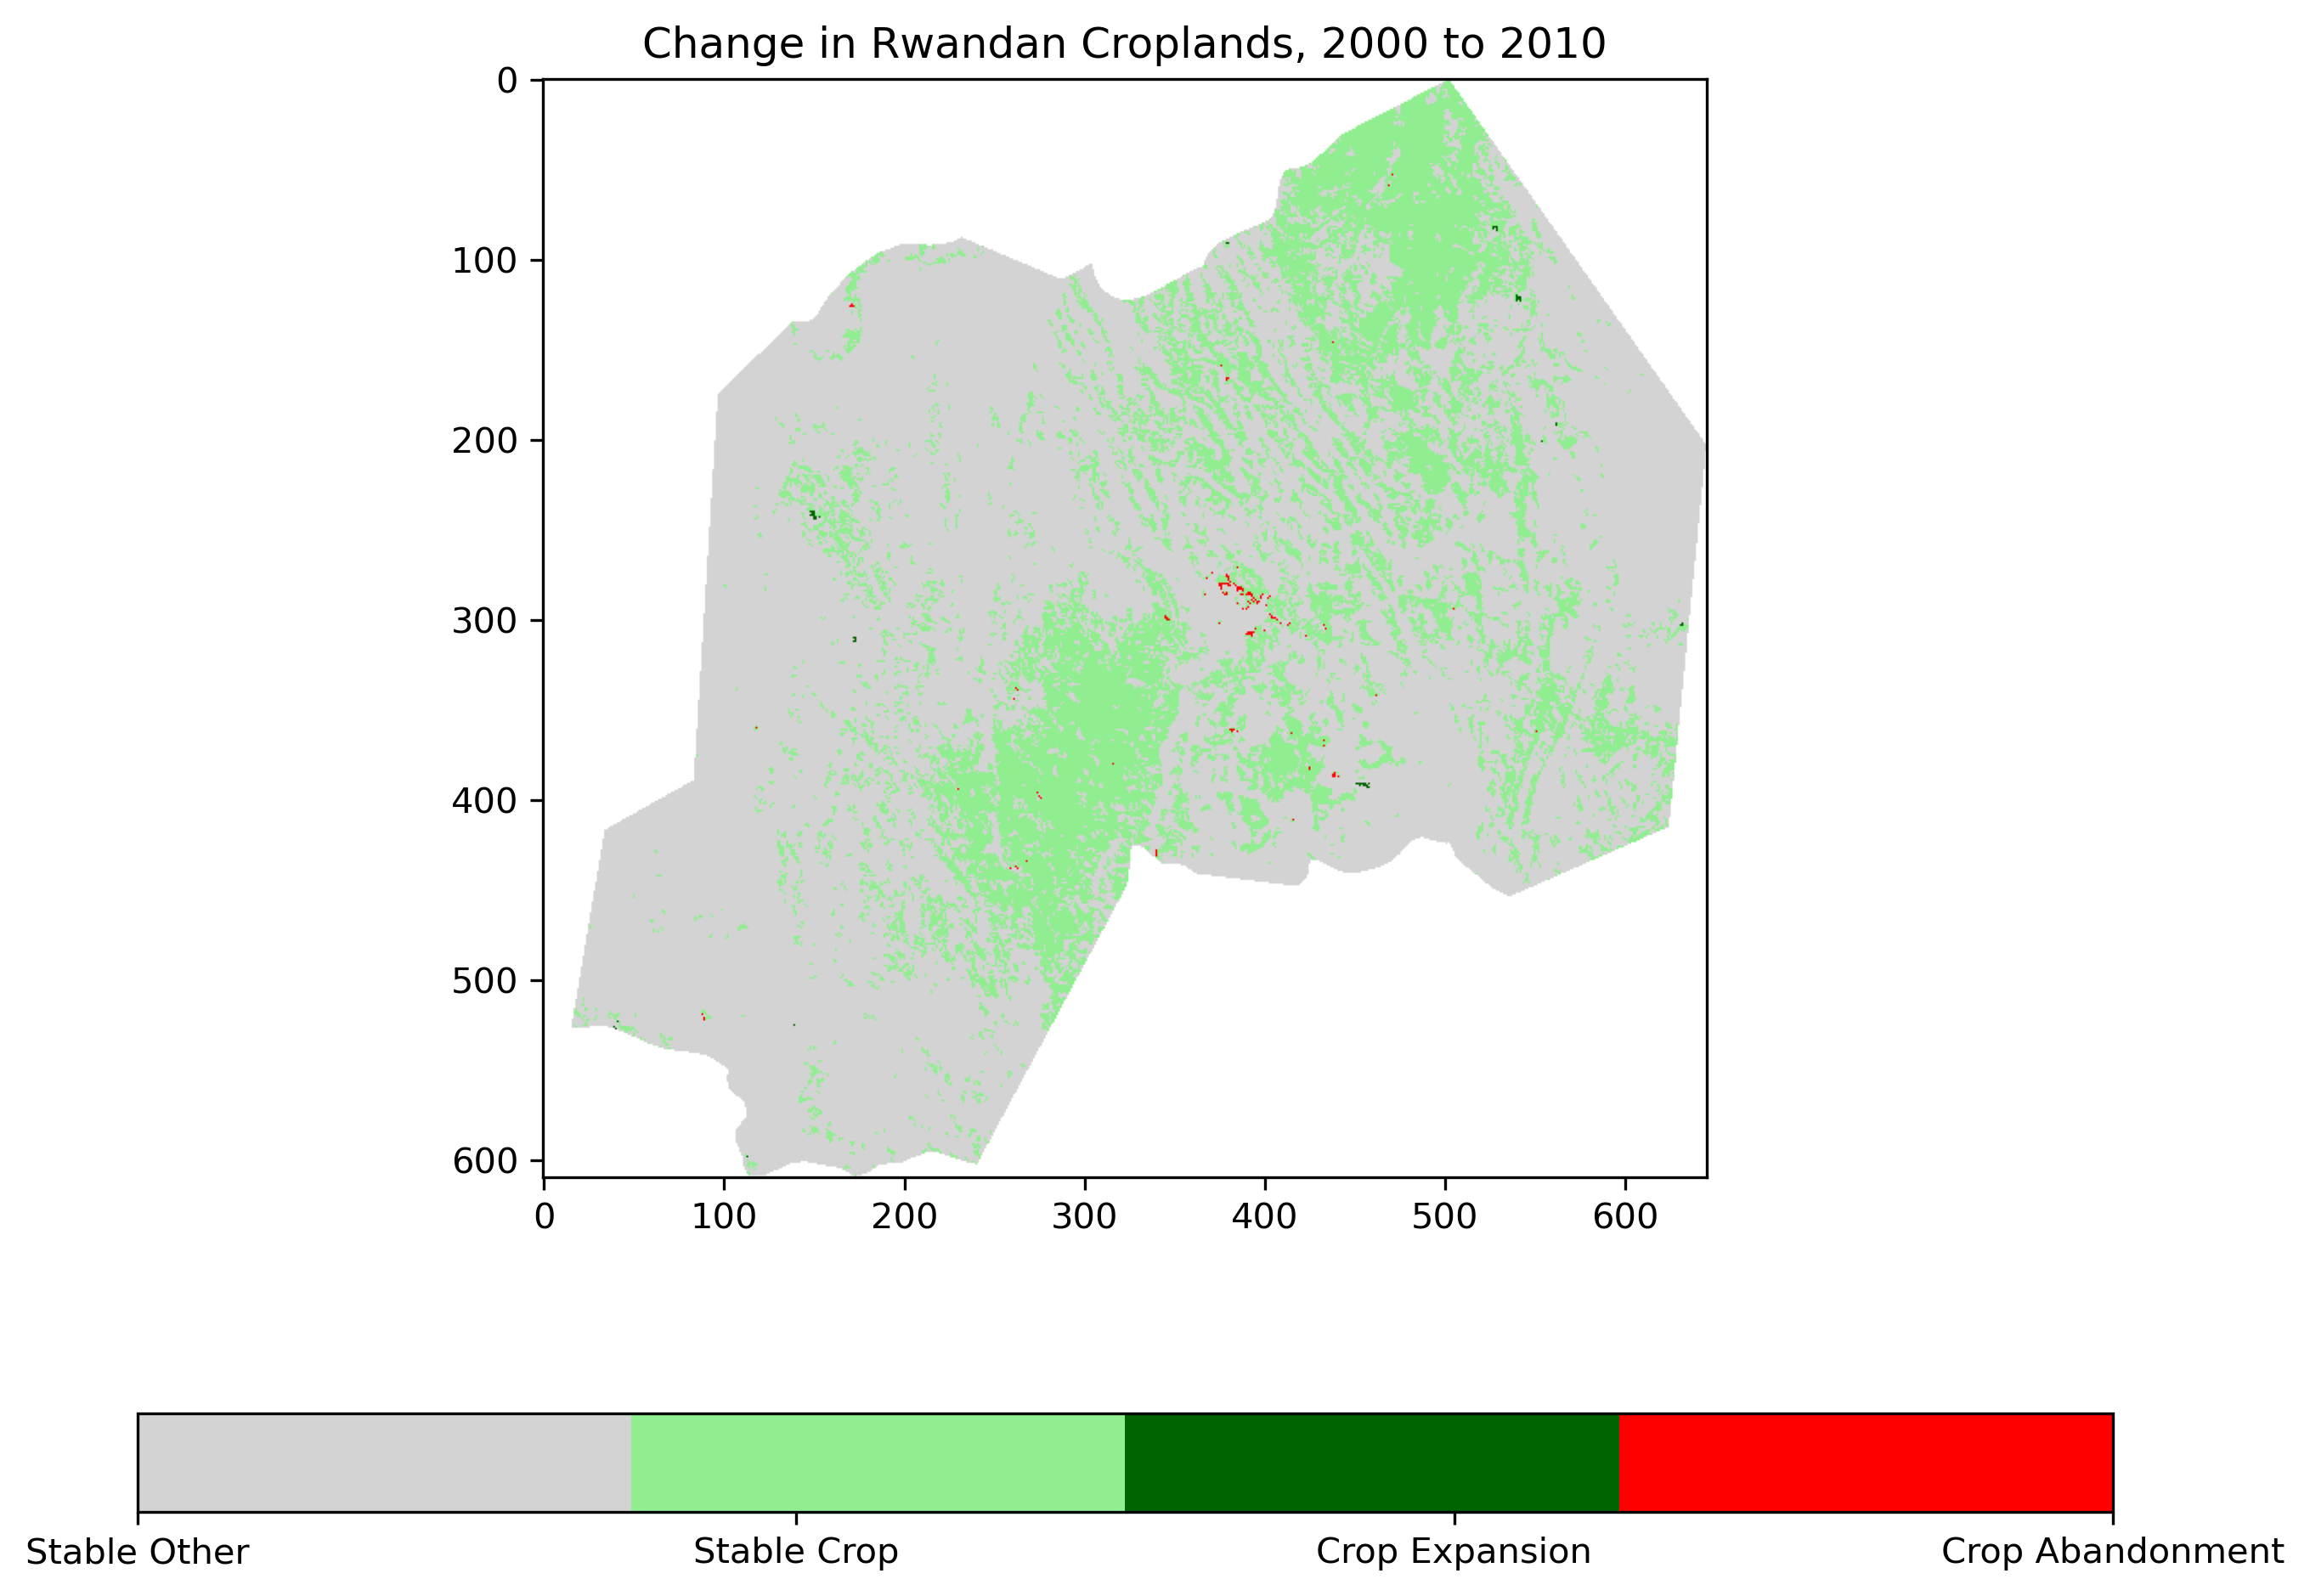

In [ ]:
# 2D Answer

# 1. -- Get array with all land use categories, with nan outside the country boundaries --
# Make the relative filepath
geotiff_file2 = 'rwanda_lulc_2010.tif'
data_directory = '../../base_data' 
geotiff_file2_path = os.path.join(data_directory, geotiff_file2)

# Open the file with gdal
rwanda_lulc_2010 = gdal.Open(geotiff_file2_path)

#Get the band
rwanda_lulc_2010_band = rwanda_lulc_2010.GetRasterBand(1)

#Get the NoData value for each band
nodata_rwanda_2010 = rwanda_lulc_2010_band.GetNoDataValue()

#Get the shapefile for the country's shape so we can mask anything outside of that
#Use the country_name and country_shape defined above for better code
if country_shape.empty:
    print(f"Error: Country '{country_name}' not found in shapefile.")
else:
    #Open Raster and Reproject Shape ---

    with rasterio.open(geotiff_file2_path) as src:
        #Get the raster's CRS
        raster_crs = src.crs

        #Reproject the country shape to match the raster's CRS
        country_shape_reprojected = country_shape.to_crs(raster_crs)

        #Convert the GeoPandas geometry into the format rasterio needs
        geoms_for_masking = country_shape_reprojected.geometry

        #Mask the Raster
        masked_array, masked_transform = mask(
            src, 
            geoms_for_masking, 
            crop = True,   #crops output array to country shape
            filled = True  #pixels outside shape set to nodata
        )
            
        # Get the NoData value from the source raster
        nodata_val = src.nodata
        
    # The output array is (bands, rows, cols). We just want the first band.
    array_country_only_2010 = masked_array[0].astype(float)
    
    # Manually convert all NoData pixels to np.nan
    if nodata_val is not None:
        array_country_only_2010[array_country_only_2010 == nodata_val] = np.nan

# 2. -- Get binary array with 2010 crop and non-crop land categories --
#Raster values corresponding to cropland, which we'll need to change to 1
#Create a boolean array with True if the value of a grid cell is in the list of crop_values, and False otherwise
crop_condition = np.isin(array_country_only_2010, crop_values)

#Create a boolean array with True for NoData (np.nan), and False otherwise
nodata_condition = np.isnan(array_country_only_2010)

#Apply nested logic to produce a binary map of the country, with nan outside the boundaries
new_array_2010 = np.where(
    nodata_condition,                   #check if nan
    np.nan,                             #if so, keep it as np.nan
    np.where(crop_condition, 1, 0)    #otherwise, check if it's a crop value and set to 1, or other and set 0
)

# 3. -- Compare 2010 to 2000 croplands, and note areas of cropland expansion and abandonment --
# Our 4 classes:
# 0 = Stable Other (0 -> 0)
# 1 = Stable Cropland (1 -> 1)
# 2 = Cropland Expansion (0 -> 1)
# 3 = Cropland Abandonment (1 -> 0)

# Create a single mask that is True wherever EITHER array is NoData
nodata_mask = np.logical_or(np.isnan(new_array_2000), np.isnan(new_array_2010))

# To create our new map of simplified land use change, we will start with an array of zeros, then add in the other classes
change_map = np.zeros(new_array_2000.shape, dtype=np.int8)

# "Paint" the other classes on top
change_map[(new_array_2000 == 1) & (new_array_2010 == 1)] = 1  # Class 2: Stable Cropland
change_map[(new_array_2000 == 0) & (new_array_2010 == 1)] = 2  # Class 3: Crop Expansion
change_map[(new_array_2000 == 1) & (new_array_2010 == 0)] = 3  # Class 4: Crop Abandonment

# Convert the map to float to store np.nan
change_map_float = change_map.astype(float)
# Apply the NoData mask. All invalid cells become np.nan
change_map_float[nodata_mask] = np.nan

# 4. -- Plot 2010 to 2000 cropland comparison --
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
ax.set_title('Change in Rwandan Croplands, 2000 to 2010')

# Create a custom 4-color colormap
colors = [
    'lightgray',  # 0 = Stable Other
    'lightgreen',  # 1 = Stable Crop
    'darkgreen', # 2 = Crop Expansion
    'red'     # 3 = Crop Abandonment
]
cmap = ListedColormap(colors)
cmap.set_bad('white', alpha=1.0) # Set NoData to white

# Plot the map
im = ax.imshow(change_map_float, cmap = cmap)

# Create a clear legend
cbar = fig.colorbar(im, ticks=[0, 1, 2, 3], orientation='horizontal')
cbar.set_ticklabels(['Stable Other', 'Stable Crop', 'Crop Expansion', 'Crop Abandonment'])

plt.show()


### Part e.

Repeat the all the steps in part d, but with the 2015 LULC map, calculating the difference between 2015 and 2010.

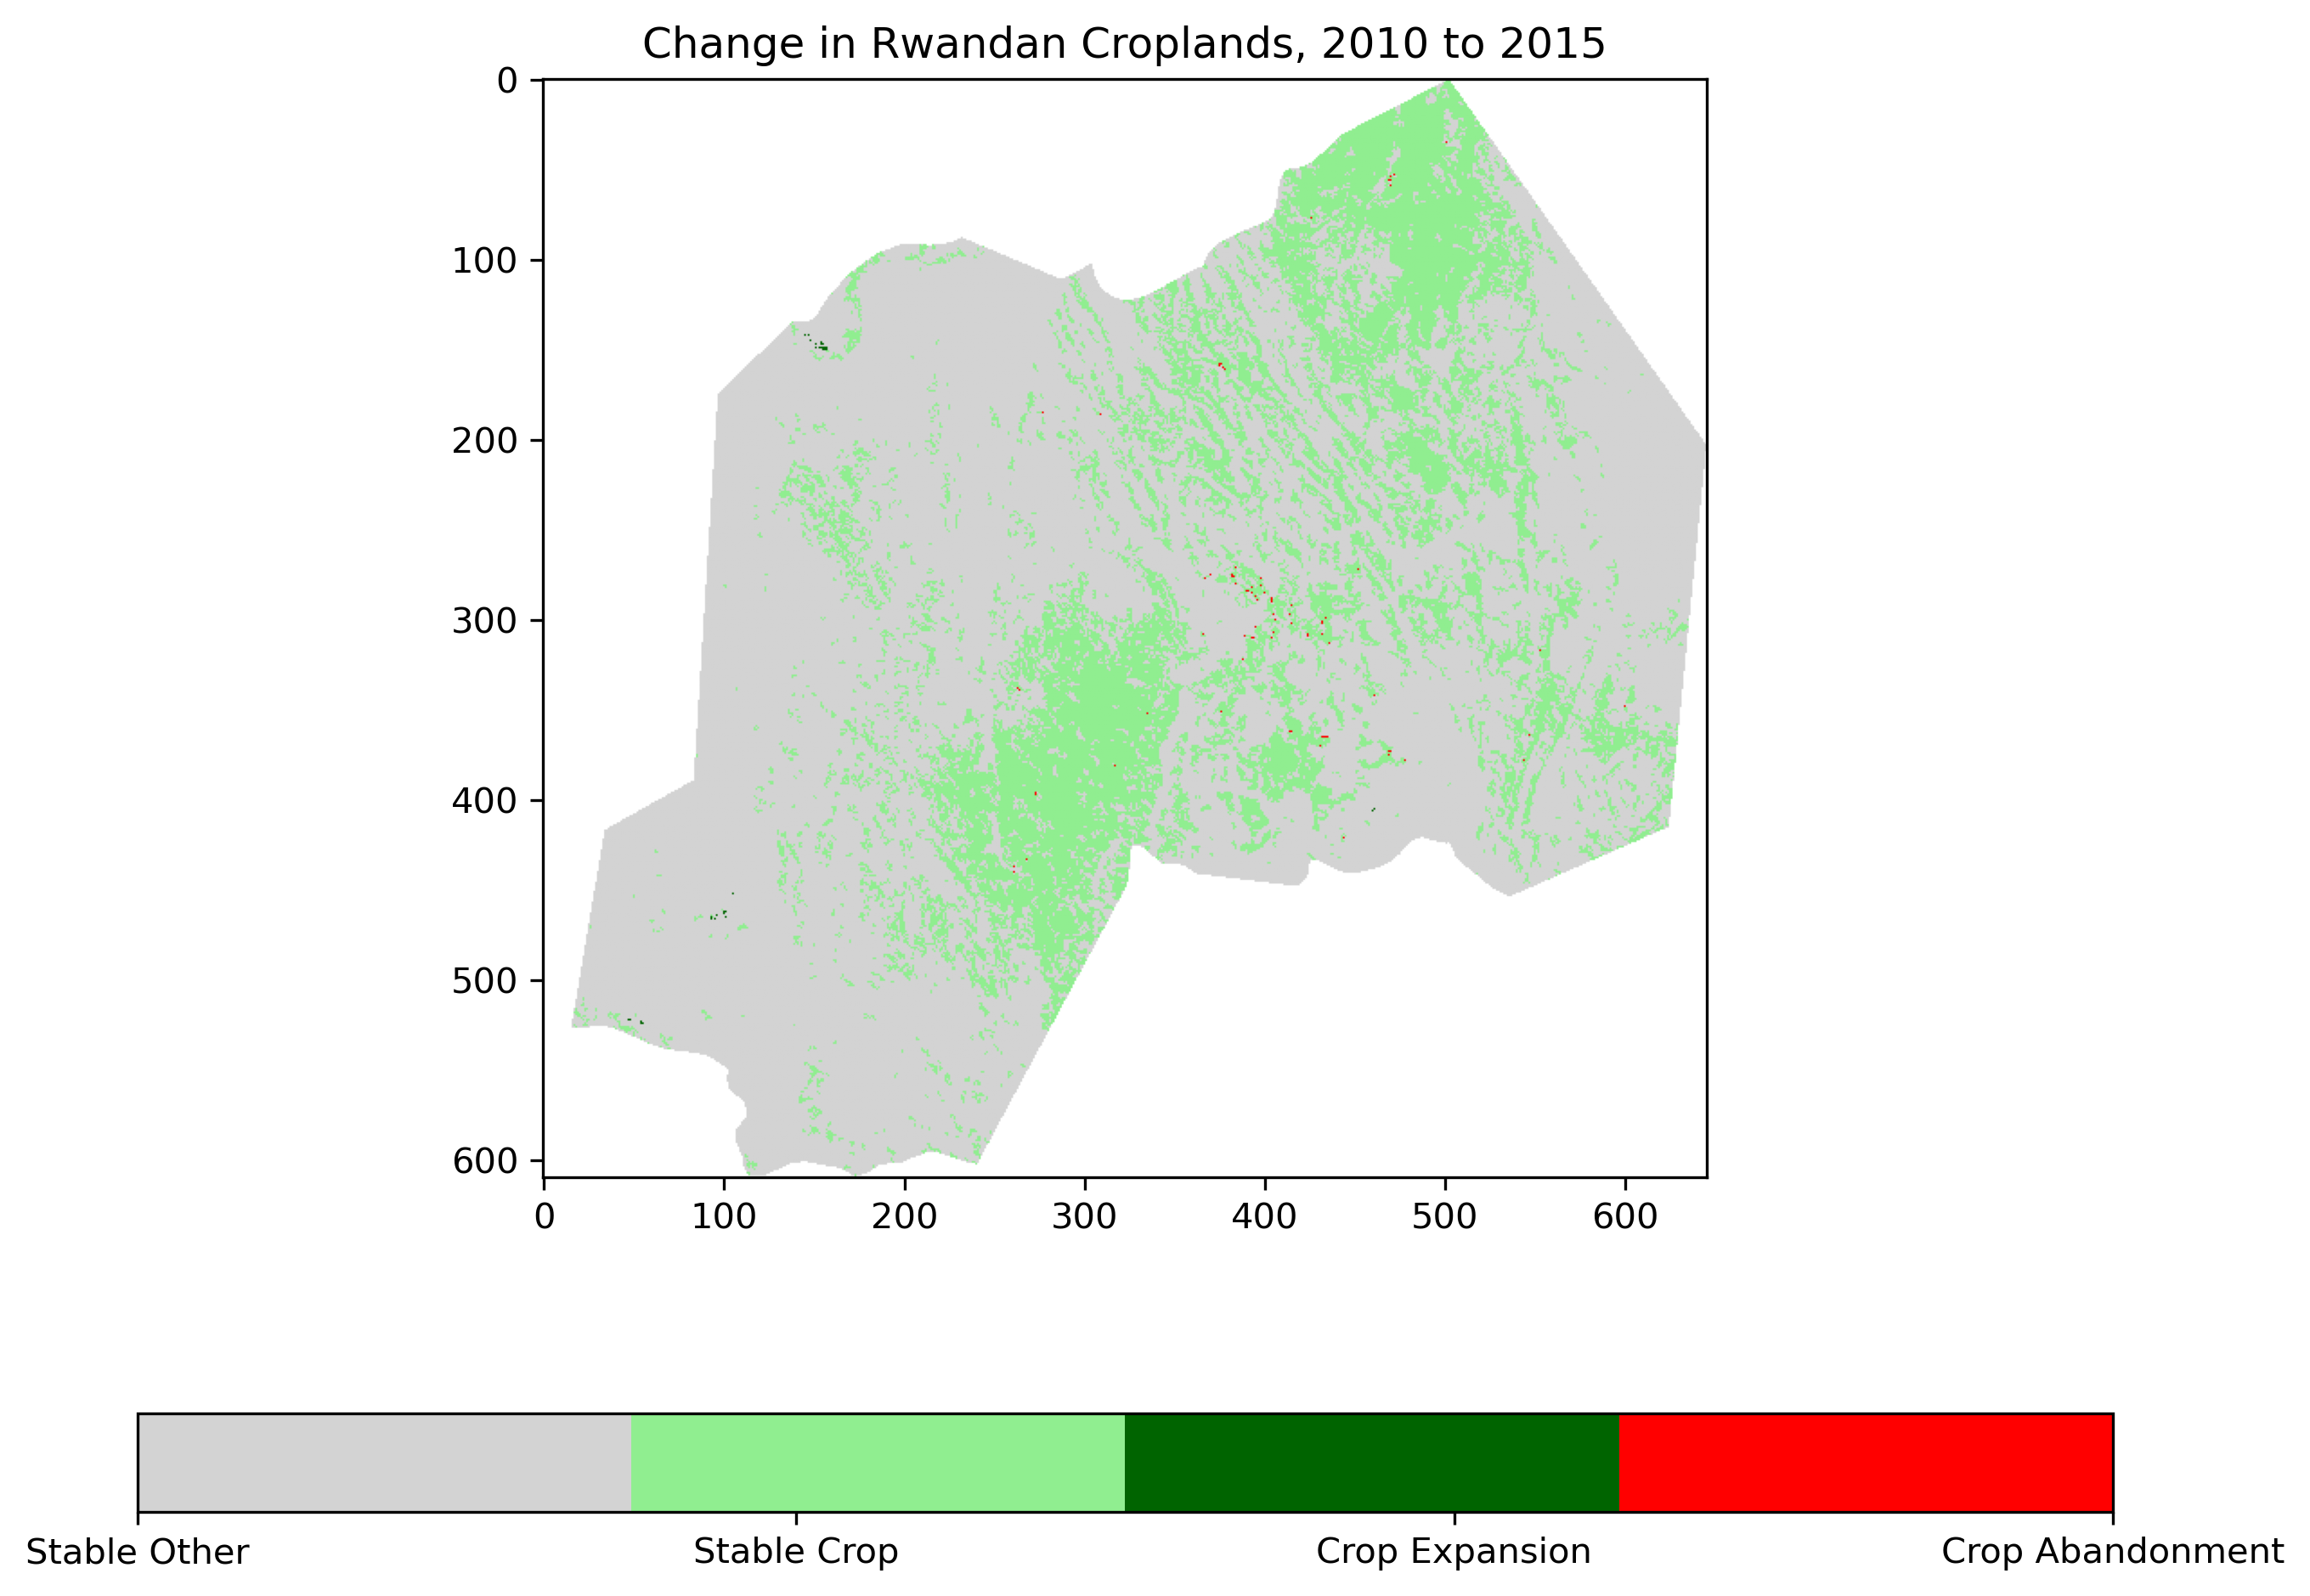

In [ ]:
# 2E Answer

# 1. -- Get array with all land use categories, with nan outside the country boundaries --
# Make the relative filepath
geotiff_file3 = 'rwanda_lulc_2015.tif'
data_directory = '../../base_data' 
geotiff_file3_path = os.path.join(data_directory, geotiff_file3)

# Open the file with gdal
rwanda_lulc_2015 = gdal.Open(geotiff_file3_path)

#Get the band
rwanda_lulc_2015_band = rwanda_lulc_2015.GetRasterBand(1)

#Get the NoData value for each band
nodata_rwanda_2015 = rwanda_lulc_2015_band.GetNoDataValue()

#Get the shapefile for the country's shape so we can mask anything outside of that
#Use the country_name and country_shape defined above for better code
if country_shape.empty:
    print(f"Error: Country '{country_name}' not found in shapefile.")
else:
    #Open Raster and Reproject Shape ---

    with rasterio.open(geotiff_file3_path) as src:
        #Get the raster's CRS
        raster_crs = src.crs

        #Reproject the country shape to match the raster's CRS
        country_shape_reprojected = country_shape.to_crs(raster_crs)

        #Convert the GeoPandas geometry into the format rasterio needs
        geoms_for_masking = country_shape_reprojected.geometry

        #Mask the Raster
        masked_array, masked_transform = mask(
            src, 
            geoms_for_masking, 
            crop = True,   #crops output array to country shape
            filled = True  #pixels outside shape set to nodata
        )
            
        # Get the NoData value from the source raster
        nodata_val = src.nodata
        
    # The output array is (bands, rows, cols). We just want the first band.
    array_country_only_2015 = masked_array[0].astype(float)

    # Manually convert all NoData pixels to np.nan
    if nodata_val is not None:
        array_country_only_2015[array_country_only_2015 == nodata_val] = np.nan

# 2. -- Get binary array with 2010 crop and non-crop land categories --
#Raster values corresponding to cropland, which we'll need to change to 1
#Create a boolean array with True if the value of a grid cell is in the list of crop_values, and False otherwise
crop_condition = np.isin(array_country_only_2015, crop_values)

#Create a boolean array with True for NoData (np.nan), and False otherwise
nodata_condition = np.isnan(array_country_only_2015)

#Apply nested logic to produce a binary map of the country, with nan outside the boundaries
new_array_2015 = np.where(
    nodata_condition,                   #check if nan
    np.nan,                             #if so, keep it as np.nan
    np.where(crop_condition, 1, 0)    #otherwise, check if it's a crop value and set to 1, or other and set 0
)

# 3. -- Compare 2010 to 2000 croplands, and note areas of cropland expansion and abandonment --
# Our 4 classes:
# 0 = Stable Other (0 -> 0)
# 1 = Stable Cropland (1 -> 1)
# 2 = Cropland Expansion (0 -> 1)
# 3 = Cropland Abandonment (1 -> 0)

# Create a single mask that is True wherever EITHER array is NoData
nodata_mask = np.logical_or(np.isnan(new_array_2010), np.isnan(new_array_2015))

# To create our new map of simplified land use change, we will start with an array of zeros, then add in the other classes
change_map = np.zeros(new_array_2010.shape, dtype=np.int8)

# "Paint" the other classes on top
change_map[(new_array_2010 == 1) & (new_array_2015 == 1)] = 1  # Class 2: Stable Cropland
change_map[(new_array_2010 == 0) & (new_array_2015 == 1)] = 2  # Class 3: Crop Expansion
change_map[(new_array_2010 == 1) & (new_array_2015 == 0)] = 3  # Class 4: Crop Abandonment

# Convert the map to float to store np.nan
change_map_float = change_map.astype(float)
# Apply the NoData mask. All invalid cells become np.nan
change_map_float[nodata_mask] = np.nan

# 4. -- Plot 2015 to 2010 cropland comparison --
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
ax.set_title('Change in Rwandan Croplands, 2010 to 2015')

# Create a custom 4-color colormap
colors = [
    'lightgray',  # 0 = Stable Other
    'lightgreen',  # 1 = Stable Crop
    'darkgreen', # 2 = Crop Expansion
    'red'     # 3 = Crop Abandonment
]
cmap = ListedColormap(colors)
cmap.set_bad('white', alpha=1.0) # Set NoData to white

# Plot the map
im = ax.imshow(change_map_float, cmap = cmap)

# Create a clear legend
cbar = fig.colorbar(im, ticks=[0, 1, 2, 3], orientation='horizontal')
cbar.set_ticklabels(['Stable Other', 'Stable Crop', 'Crop Expansion', 'Crop Abandonment'])

plt.show()

### Part f.

Use the two cropland binary rasters you processed above and make a new raster as follows:

0 = Never cropland
1 = Cropland in 2000 only
2 = Cropland in 2010 only
3 = Cropland in 2015 only
4 = Cropland in 2000 and 2010
5 = Cropland in 2000 and 2015
6 = Cropland in 2010 and 2015
7 = Cropland in 2000, 2010, and 2015

Plot this raster using imshow. Add a legend indicating what each value means.

A tip for you: when you are combining multiple logical statements in numpy, each individual logical statement must be surrounded by parentheses. Additionally, you have to use the bitwise logical operators & and | instead of the normal logical operators and and or (numpy requires this for specificity).

For example, np.where((a == 1) & (b == 2)) will return the indices where a is 1 and b is 2. If you do np.where(a == 1 & b == 2) or np.where((a == 1) and (b == 2)), you will get an error.

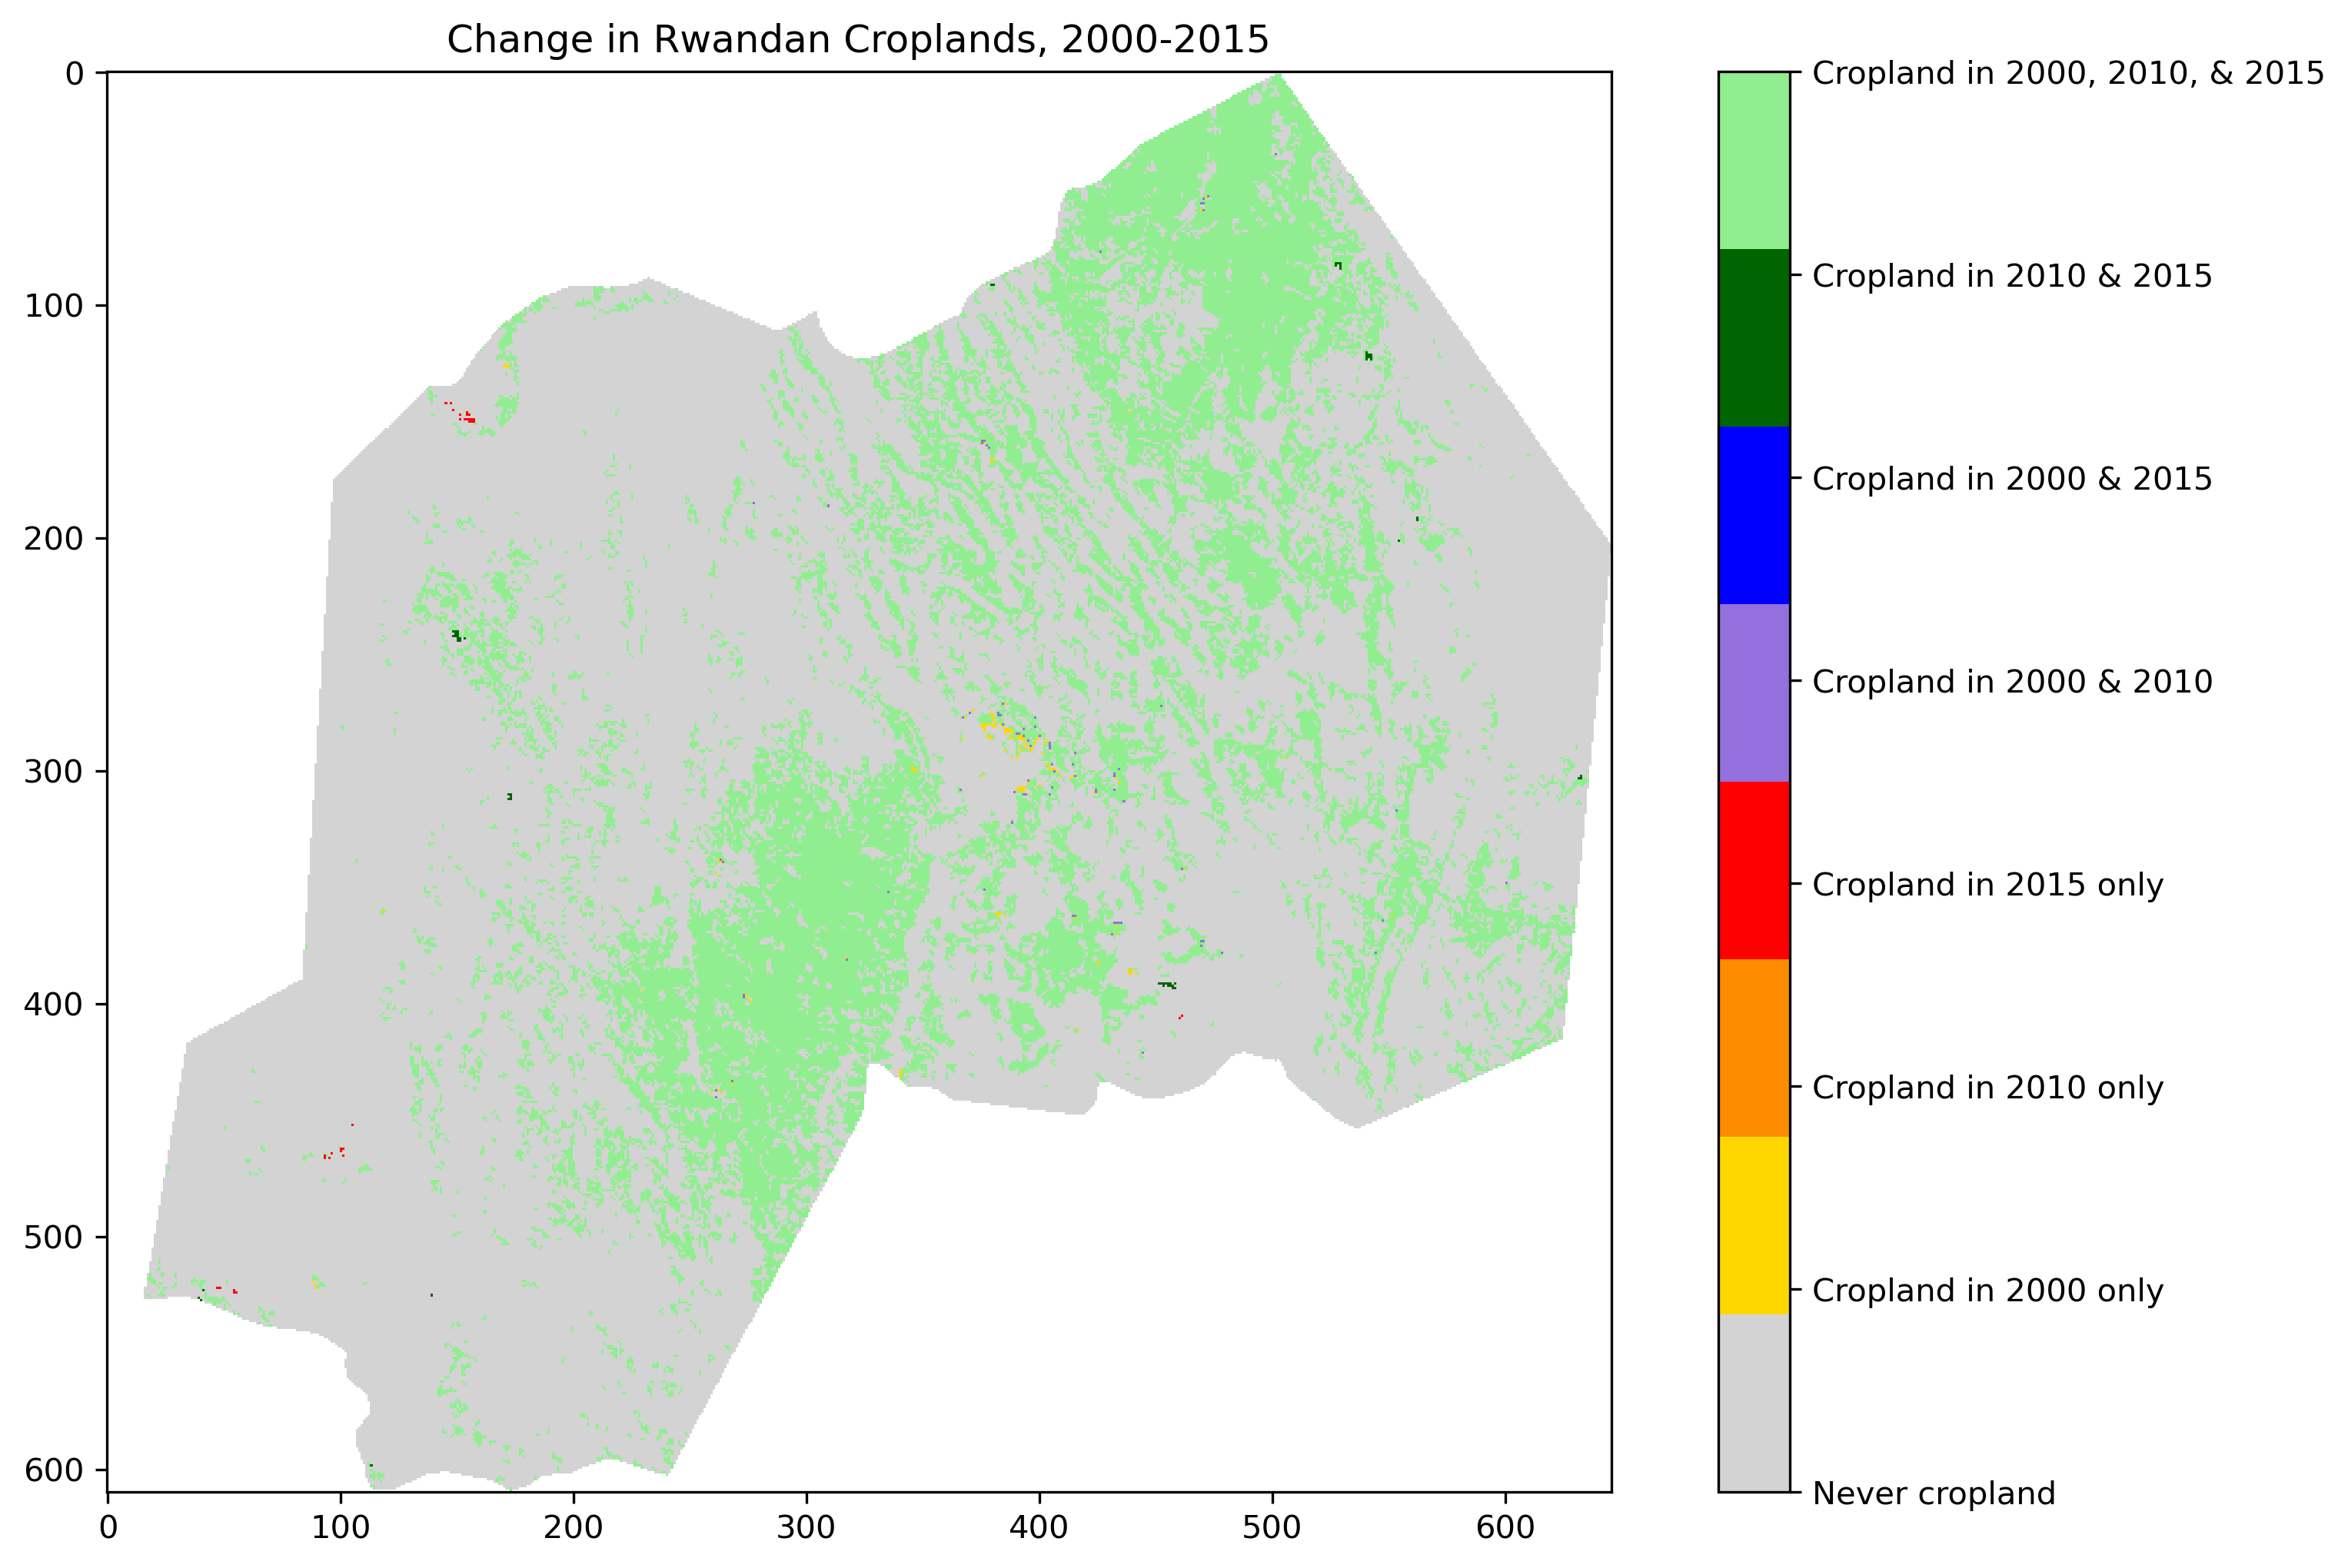

In [ ]:
#2F Answer

# -- Compare 2015, 2010, and 2000 croplands, and note areas of cropland expansion and abandonment --
# Our 8 classes:
# 0 = Never cropland
# 1 = Cropland in 2000 only
# 2 = Cropland in 2010 only
# 3 = Cropland in 2015 only
# 4 = Cropland in 2000 and 2010
# 5 = Cropland in 2000 and 2015
# 6 = Cropland in 2010 and 2015
# 7 = Cropland in 2000, 2010, and 2015

# Create a single mask that is True wherever ANY array is NoData
nodata_mask = np.logical_or(np.isnan(new_array_2000), np.isnan(new_array_2010), np.isnan(new_array_2015))

# To create our new map of simplified land use change, we will start with an array of zeros, then add in the other classes
change_map = np.zeros(new_array_2000.shape, dtype=np.int8)     # Default: class 0, Never cropland

# "Paint" the other classes on top
change_map[(new_array_2000 == 1) & (new_array_2010 == 1) & (new_array_2015 == 1)] = 7  # Cropland in 2000, 2010, and 2015
change_map[(new_array_2000 == 0) & (new_array_2010 == 1) & (new_array_2015 == 1)] = 6  # Cropland in 2010 and 2015
change_map[(new_array_2000 == 1) & (new_array_2010 == 0) & (new_array_2015 == 1)] = 5  # Cropland in 2000 and 2015
change_map[(new_array_2000 == 1) & (new_array_2010 == 1) & (new_array_2015 == 0)] = 4  # Cropland in 2000 and 2010
change_map[(new_array_2000 == 0) & (new_array_2010 == 0) & (new_array_2015 == 1)] = 3  # Cropland in 2015 only
change_map[(new_array_2000 == 0) & (new_array_2010 == 1) & (new_array_2015 == 0)] = 2  # Cropland in 2010 only
change_map[(new_array_2000 == 1) & (new_array_2010 == 0) & (new_array_2015 == 0)] = 1  # Cropland in 2000 only

# Convert the map to float to store np.nan
change_map_float = change_map.astype(float)
# Apply the NoData mask. All invalid cells become np.nan
change_map_float[nodata_mask] = np.nan

# Plot cropland comparison
fig, ax = plt.subplots(figsize=(12, 8), dpi=300) # Made the figure wider
ax.set_title('Change in Rwandan Croplands, 2000-2015')

# Create a custom colormap
colors = [
    'lightgray',      # 0 = Never cropland
    '#FFD700',      # 1 = 2000 only (Gold)
    'darkorange',     # 2 = 2010 only
    'red',            # 3 = 2015 only
    '#9370DB',      # 4 = 2000 & 2010 (Medium Purple)
    'blue',           # 5 = 2000 & 2015
    'darkgreen',      # 6 = 2010 & 2015
    'lightgreen'      # 7 = All three
]

labels = [
    'Never cropland',
    'Cropland in 2000 only',
    'Cropland in 2010 only',
    'Cropland in 2015 only',
    'Cropland in 2000 & 2010',
    'Cropland in 2000 & 2015',
    'Cropland in 2010 & 2015',
    'Cropland in 2000, 2010, & 2015'
]

#Create colormap
cmap = ListedColormap(colors)

#Set nan to white
cmap.set_bad('white', alpha=1.0)

#Plot the map
im = ax.imshow(change_map_float, cmap=cmap)

#Add legend
# Vertical orientation prevents labels from overlapping
cbar = fig.colorbar(im, ticks=[0, 1, 2, 3, 4, 5, 6, 7], orientation='vertical')
cbar.set_ticklabels(labels)

plt.show()

### Part g.

Describe your results. What do you notice about the spatial patterns of cropland expansion and abandonment? What do you think might be driving these patterns? Were they clustered in any specific area? Were the changes the same between 2000-2010 and 2010-2015?

2G Answer

Cropland expansion seems to be concentrated in fewer, relatively large spots. These tend to be away from the biggest cities, and I speculate they may be near new water sources. There is also a significant zone of new expansion at the northwest border that appears to be in or around the Birunga National Park, and which became cropland only in 2015. Interestingly, the northeast border of Birunga features some cropland abandonment. This pattern suggests that there is some crop-friendly attribute such as water or fertile soil concentrated in the soutwest of the national park. Meanwhile, most cropland abandonment appears as clustered smaller dots in rings around cities. The most prominant example of this is around Kigali, the capital. I suspect that the cities are growing, and the surrounding farmland is being converted to residential areas, or possibly industry to take advantage of the urban concentration of labor. 

## Question 2

For this question, you will analyze crops using two datasets:

1. FAOSTAT Production_Crops_E_All_Data_(Normalized).csv. You could download it yourself but please use the one in the Class's Data Directory.
2. MAPSPAM (Spatial Production Allocation Mode). You can find the download listing here: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/PRFF8V Download the readme and all of the files that end with .geotiff.zip. Unzip them and put them in a folder called spam in your Class's Data Directory. This is a big download, so it may take a while. Go watch a show or something. I don't know, what do people do nowadays for fun?. 

Sidenote: MAPSPAM was a competitor to the EARTHSTAT data we showed in class before. However, MAPSPAM continues to be updated and is more open-source, so I am in the process of switching my whole GTAP-InVEST model to it. 

You will choose 5 crops that interest you, making sure to select crops that are in both MAPSPAM and FAOSTAT dataset. You will want to refer to the ReadMe_v2r0_Global.txt file, which was available at the same download site for MAPSPAM, to identify what each of the different crops mean. For each crop you choose (use a loop), calculate the global sum of production tonnage for irrigated crops, all rainfed crops combined but excluding subsistence crops, and for all crops together. Report those values via print(). 

Next, for the same crops, compare how the value you calculated above compares to the value in the FAOSTAT dataset. To do this, you will need to use Pandas to load the CSV and then figure out how to get just the production tonnage values for the crops you are interested in. Interpret your results for your crops. Is FAO higher/lower than MAPSPAM? Do you notice any patterns to the difference?

Q2 Narrative Answer
FAOSTAT world production numbers are broadly similar to MAPSPAM production totals for 2010. FAOSTAT numbers are higher for tea and coconuts, by 1.5% and 1.7% respectively. MAPSPAM numbers are higher for oil palm fruit (2.6%), wheat (5.3%), and potatoes (5.4%).  In this sample, it appears that FAOSTAT totals tend to be a bit lower, but our sample size is far too small to make any claim to that effect. In fact, with coding ambiguities such as oil palm fruit vs palm oil vs palm kernel oil, I was anticipating some larger discrepencies than I found.

In [ ]:
# Question 2 answer code

# --- Part A, MAPSPAM data ---
# Create a function to open gdal rasters, handle nodata and nan cells, and return the total sum
def get_production_sum(filepath):
    """
    Opens a GDAL raster, handles NoData, and returns the total sum.
    Returns 0.0 if the file cannot be opened.
    """
    ds = gdal.Open(filepath)
    
    # Check if file opened successfully
    if ds is None:
        print(f"  Warning: Could not open {filepath}")
        return 0.0 # Return 0 so it doesn't break our sum
    
    band = ds.GetRasterBand(1)
    nodata = band.GetNoDataValue()
    arr = band.ReadAsArray()
    
    # Handle NoData and nan values before summing
    if nodata is not None:
        mask = np.logical_or(arr == nodata, np.isnan(arr))
        arr[mask] = 0
    else:
        # Just in case there are nans but no nodata value
        arr[np.isnan(arr)] = 0
            
    total_sum = np.sum(arr, dtype=np.float64)   # Return the more precise float type
    
    # Clean up
    ds = None
    band = None
    
    return total_sum

#Go up one level relative to your current working directory, then go to spam folder in base_data directory
data_directory = '../../base_data/spam' 

# Create a dictionary listing chosen crops and their descriptions for better interpretation
crop_names_map = {
    'OILP': 'oil palm',
    'TEAS': 'tea',
    'CNUT': 'coconut',
    'WHEA': 'wheat',
    'POTA': 'potato'
}

# Create a dictionary to store results
irrigation_production = {}
rainfed_production = {}
all_tech_production = {}

# Set up for loop to work through each crop and print the production totals
# Use .items() to get both the code and full name at once
for crop_code, full_name in crop_names_map.items():
    print(f"Production total tonnage for {full_name} ({crop_code})...")

    # Calculate irrigated production
    geotiff_filename_I = f"spam2010V2r0_global_P_{crop_code}_I.tif"
    geotiff_file_path_I = os.path.join(data_directory, geotiff_filename_I)
    sum_I = get_production_sum(geotiff_file_path_I)
    irrigation_production[full_name] = sum_I

    # Calculate "Rainfed High Inputs" production
    geotiff_filename_H = f"spam2010V2r0_global_P_{crop_code}_H.tif"
    geotiff_file_path_H = os.path.join(data_directory, geotiff_filename_H)
    sum_H = get_production_sum(geotiff_file_path_H)

    # Calculate "Rainfed Low Inputs" production
    geotiff_filename_L = f"spam2010V2r0_global_P_{crop_code}_L.tif"
    geotiff_file_path_L = os.path.join(data_directory, geotiff_filename_L)
    sum_L = get_production_sum(geotiff_file_path_L)    

    # Calculate Rainfed production (no subsistence) from sum of H + L
    total_rainfed = sum_H + sum_L
    rainfed_production[full_name] = total_rainfed

    # Calculate all technologies production
    geotiff_filename_A = f"spam2010V2r0_global_P_{crop_code}_A.tif"
    geotiff_file_path_A = os.path.join(data_directory, geotiff_filename_A)
    sum_A = get_production_sum(geotiff_file_path_A)
    all_tech_production[full_name] = sum_A

    # --- Print the results for this crop ---
    print(f"  Total Production (Irrigated): {sum_A:,.2f}")
    print(f"  Total Production (Rainfed H+L): {total_rainfed:,.2f}")
    print(f"  Total Production (All Tech): {sum_A:,.2f}\n")




Production total tonnage for oil palm (OILP)...
  Total Production (Irrigated): 229,629,513.49
  Total Production (Rainfed H+L): 210,563,764.66
  Total Production (All Tech): 229,629,513.49

Production total tonnage for tea (TEAS)...
  Total Production (Irrigated): 4,553,133.01
  Total Production (Rainfed H+L): 4,139,427.70
  Total Production (All Tech): 4,553,133.01

Production total tonnage for coconut (CNUT)...
  Total Production (Irrigated): 59,558,063.38
  Total Production (Rainfed H+L): 46,947,600.22
  Total Production (All Tech): 59,558,063.38

Production total tonnage for wheat (WHEA)...
  Total Production (Irrigated): 674,830,716.50
  Total Production (Rainfed H+L): 413,772,971.49
  Total Production (All Tech): 674,830,716.50

Production total tonnage for potato (POTA)...
  Total Production (Irrigated): 346,402,155.90
  Total Production (Rainfed H+L): 229,317,563.40
  Total Production (All Tech): 346,402,155.90



In [ ]:
# --- Part B, FAOSTAT data ---
# Set our file path and read in CSV
data_directory = '../../base_data'
faostat_filename = 'Production_Crops_E_All_Data_(Normalized).csv'
faostat_path = os.path.join(data_directory, faostat_filename)

#FAOSTAT file is encoded in latin1, so we must specify or fail to read in the csv
faostat_production = pd.read_csv(faostat_path, encoding='latin1') 

# Print the dataframe to explore data (Commented out for concise pdf)
# print(faostat_production)

# See the exact column names
print(faostat_production.columns)

# Find all unique values in the 'Element' column
print(faostat_production['Element'].unique())
# We will use "Production"

# Map item codes (as strings) to the full names for printing
item_name_map = {
    '667': 'Tea',         
    '249': 'Coconuts', 
    '15': 'Wheat',              
    '116': 'Potatoes',           
    '254': 'Oil palm fruit'   
}

# Get a list of item codes we will use to filter
target_item_codes = list(item_name_map.keys())

# Filter columns to match MAPSPAM data
element_for_filter = 'Production' 
year_for_filter = 2010
WORLD_CODE = 5000 # FAOSTAT already has aggregated production numbers at world level, so we'll just use that

# Make sure 'Item Code' is treated as a string to match target_item_codes list
faostat_production['Item Code'] = faostat_production['Item Code'].astype(str)

filtered_df = faostat_production[
    (faostat_production['Year'] == year_for_filter) &
    (faostat_production['Element'] == element_for_filter) &
    (faostat_production['Item Code'].isin(target_item_codes)) &
    (faostat_production['Area Code'] == WORLD_CODE)
]

# Group by item and sum the Value column
summed_values = filtered_df.groupby('Item Code')['Value'].sum()

print(f"\n Total Production for {year_for_filter}: ")

# Use a for loop to fetch a summed_value for each item code in our target list
for item_code, total_sum in summed_values.items():
    # Use the map to get the full name
    full_name = item_name_map[item_code]
    print(f"{full_name}: {total_sum:,.0f} (tonnes)")

Index(['Area Code', 'Area', 'Item Code', 'Item', 'Element Code', 'Element',
       'Year Code', 'Year', 'Unit', 'Value', 'Flag'],
      dtype='object')
['Area harvested' 'Yield' 'Production']

 Total Production for 2010: 
Potatoes: 328,616,920 (tonnes)
Wheat: 640,802,665 (tonnes)
Coconuts: 60,543,524 (tonnes)
Oil palm fruit: 223,773,974 (tonnes)
Tea: 4,621,942 (tonnes)


In [ ]:
# --- Part C, Comparing MAPSPAM & FAOSTAT Production Tonnage values  --- 
# Link the datasets with MAPSPAM dictionary key & FAOSTAT item codes
link_map = {
    'oil palm': '254',
    'tea': '667',
    'coconut': '249',
    'wheat': '15',
    'potato': '116'
}

# Build a list of data for a new, combined dataframe by iterating through crop names and fetching values for each from MAPSPAM and then FAOSTAT
comparison_data = []

for mapspam_key, faostat_code in link_map.items():
    
    # Get the full crop name from FAOSTATmap
    full_name = item_name_map[faostat_code]
    
    # Get the MAPSPAM value
    mapspam_val = all_tech_production[mapspam_key]
    
    # Get the FAOSTAT value
    faostat_val = summed_values.loc[faostat_code]
    
    # Append the data as a dictionary
    comparison_data.append({
        'Crop': full_name,
        'MAPSPAM (tonnes)': mapspam_val,
        'FAOSTAT (tonnes)': faostat_val
    })

# Create the dataframe out of the list of data created above
comparison_df = pd.DataFrame(comparison_data)

# Add a difference column for easy comparison
comparison_df['Difference (MAPSPAM - FAOSTAT)'] = comparison_df['MAPSPAM (tonnes)'] - comparison_df['FAOSTAT (tonnes)']

# Print the table with nice formatting
pd.options.display.float_format = '{:,.0f}'.format   # Formats all floats with commas and no decimals

print("\n--- Comparison of MAPSPAM vs. FAOSTAT Production (2010) ---")
print(comparison_df.to_string(index=False))


--- Comparison of MAPSPAM vs. FAOSTAT Production (2010) ---
          Crop  MAPSPAM (tonnes)  FAOSTAT (tonnes)  Difference (MAPSPAM - FAOSTAT)
Oil palm fruit       229,629,513       223,773,974                       5,855,539
           Tea         4,553,133         4,621,942                         -68,809
      Coconuts        59,558,063        60,543,524                        -985,461
         Wheat       674,830,716       640,802,665                      34,028,051
      Potatoes       346,402,156       328,616,920                      17,785,236


In [ ]:
# Helper code for answer 2B above, to get correct items and item codes for each commodity

# Create a 'tea' filter (case-insensitive)
tea_mask = faostat_production['Item'].str.contains("tea", case=False, na=False)

# Create a 'potato' filter (case-insensitive)
potato_mask = faostat_production['Item'].str.contains("potato", case=False, na=False)

# Create a 'wheat' filter (case-insensitive)
wheat_mask = faostat_production['Item'].str.contains("wheat", case=False, na=False)

# Create a 'coconut' filter (case-insensitive)
coconut_mask = faostat_production['Item'].str.contains("coconut", case=False, na=False)

# Create a 'oil palm' filter (case-insensitive)
oilp_mask = faostat_production['Item'].str.contains("oil palm", case=False, na=False)

# Combine the filters: find rows that match EITHER tea OR potato
combined_mask = tea_mask | potato_mask | wheat_mask | coconut_mask | oilp_mask

# Apply the filter to the DataFrame
matches_df = faostat_production[combined_mask]

# --- Get the unique pairs ---
# Select only the 'Item' and 'Item Code' columns, then drop duplicates
# This gives you a clean lookup table of the matches.
unique_matches = matches_df[['Item', 'Item Code']].drop_duplicates()

print("\n--- 🍵🥔 Found Item Codes ---")
print(unique_matches)


--- 🍵🥔 Found Item Codes ---
                 Item Item Code
3801         Potatoes       116
5872            Wheat        15
32069        Coconuts       249
37871  Oil palm fruit       254
39997  Sweet potatoes       122
59477             Tea       667
84395       Buckwheat        89


In [ ]:
# --- 1. Define your filters ---
tea_code = '667' # Assuming this is your 'Tea leaves' code
element_to_filter_by = 'Production' 
year_to_filter_by = 2010

# --- 2. Create a filter mask ---
tea_debug_mask = (
    (faostat_production['Year'] == year_to_filter_by) &
    (faostat_production['Element'] == element_to_filter_by) &
    (faostat_production['Item Code'] == tea_code)
)

# --- 3. Apply the mask and print the 'Area' and 'Value' ---
print(f"--- Debugging 'Production' for 'Tea' ({tea_code}) in {year_to_filter_by} ---")

# We sort by 'Value' (descending) to see the biggest numbers (the aggregates) at the top
print(faostat_production[tea_debug_mask][['Area Code', 'Area', 'Value']].sort_values(by='Value', ascending=False))

--- Debugging 'Production' for 'Tea' (667) in 2010 ---
         Area Code                               Area     Value
1836874       5000                              World 4,621,942
2089103       5300                               Asia 3,844,900
2459973       5815  Low Income Food Deficit Countries 1,927,830
2121177       5302                       Eastern Asia 1,554,756
2143632       5303                      Southern Asia 1,520,230
...            ...                                ...       ...
1031344        133                               Mali       107
1954482       5105                     Western Africa       107
1088285        273                         Montenegro       100
1448372        196                         Seychelles        49
1251614        166                             Panama         0

[75 rows x 3 columns]
